# Shoreline change based on land elevation data (AHN 4 and 5)

In [147]:
# read two tiff files (ahn4_merged_cropped.tiff and ahn5_merged_cropped.tiff) from "data_preprocessed\AHN45"
# and subtract the two files and save the result as "ahn45_difference.tiff" in the same folder

import rasterio
import numpy as np

with rasterio.open("data_preprocessed/AHN45/ahn4_merged_cropped.tiff") as src1:
    band1 = src1.read(1)
    transform = src1.transform # to transform the coordinates
    # print the metadata
    print(src1.meta)
    # print coordinate reference system
    print(src1.crs)

with rasterio.open("data_preprocessed/AHN45/ahn5_merged_cropped.tiff") as src2:
    band2 = src2.read(1)

# Subtract the two bands
difference = band1 - band2

# Save the result
with rasterio.open("data_preprocessed/AHN45/ahn45_difference.tiff", "w", **src1.meta) as dst:
    dst.write(difference, 1)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 1200, 'height': 1200, 'count': 1, 'crs': CRS.from_wkt('PROJCS["Amersfoort / RD New",GEOGCS["Amersfoort",DATUM["Amersfoort",SPHEROID["Bessel 1841",6377397.155,299.1528128,AUTHORITY["EPSG","7004"]],AUTHORITY["EPSG","6289"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4289"]],PROJECTION["Oblique_Stereographic"],PARAMETER["latitude_of_origin",52.1561605555556],PARAMETER["central_meridian",5.38763888888889],PARAMETER["scale_factor",0.9999079],PARAMETER["false_easting",155000],PARAMETER["false_northing",463000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","28992"]]'), 'transform': Affine(5.0, 0.0, 151800.0,
       0.0, -5.0, 514000.0)}
EPSG:28992


Min: -0.67342323
Max: 13.542089
Mean: 0.02874547
Std: 0.21018371


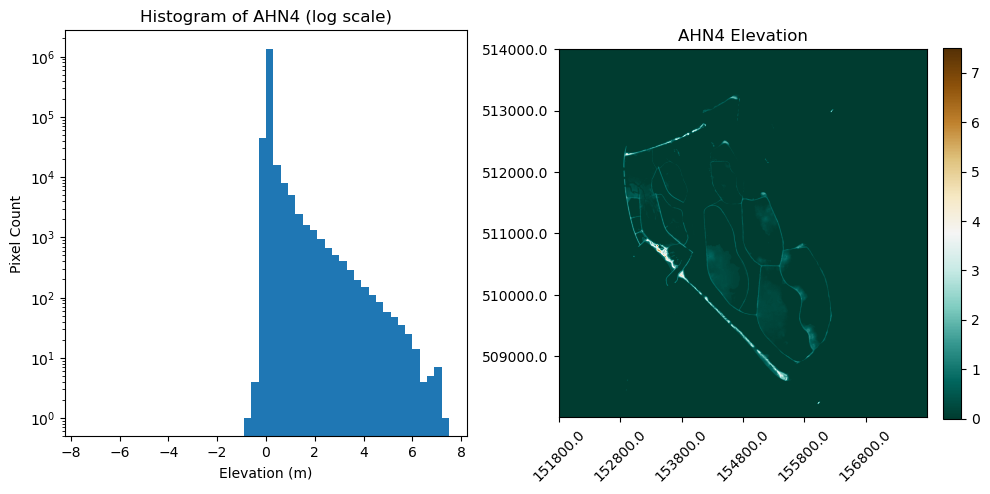

In [140]:
# read ahn4_merged_cropped.tiff and print the min, max, mean, std
# also plot a histogram of the values
# also plot the elevation as an image

import matplotlib.pyplot as plt
with rasterio.open("data_preprocessed/AHN45/ahn4_merged_cropped.tiff") as src:
    ahn4 = src.read(1)
    print("Min:", np.min(ahn4))
    print("Max:", np.max(ahn4))
    print("Mean:", np.mean(ahn4))
    print("Std:", np.std(ahn4))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(ahn4.flatten(), bins=50, range=(-7.5, 7.5), log=True)
    plt.title("Histogram of AHN4 (log scale)")
    plt.xlabel("Elevation (m)")
    plt.ylabel("Pixel Count")

    plt.subplot(1, 2, 2)
    vmax = np.max(np.abs(ahn4))
    img = plt.imshow(ahn4, cmap="bwr", vmin=-vmax, vmax=vmax)
    plt.title("AHN4 Elevation")

    # compute tick positions in pixel coordinates
    xticks = np.arange(0, ahn4.shape[1], 200)
    yticks = np.arange(0, ahn4.shape[0], 200)

    # convert pixel indices to map coordinates using the affine transform
    # transform * (col, row) -> (x, y)
    xtick_labels = [round((transform * (int(c), 0))[0], 2) for c in xticks]
    ytick_labels = [round((transform * (0, int(r)))[1], 2) for r in yticks]

    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
    plt.yticks(ticks=yticks, labels=ytick_labels)
    vmin, vmax = 0, 7.5
    img = plt.imshow(ahn4, cmap="BrBG_r", vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Min: -0.50708956
Max: 12.94658
Mean: 0.021476785
Std: 0.24575888


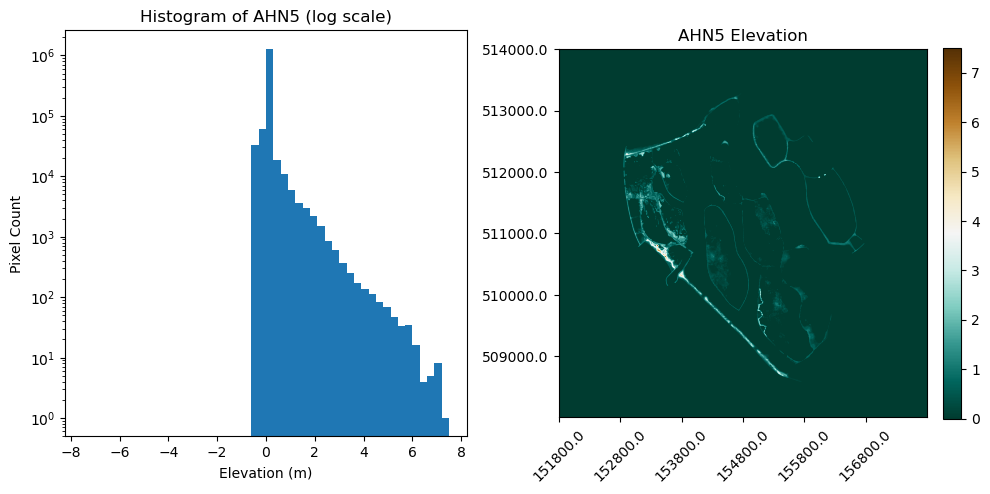

In [141]:
# read ahn5_merged_cropped.tiff and print the min, max, mean, std
# also plot a histogram of the values
# also plot the elevation as an image

import matplotlib.pyplot as plt
with rasterio.open("data_preprocessed/AHN45/ahn5_merged_cropped.tiff") as src:
    ahn5 = src.read(1)
    print("Min:", np.min(ahn5))
    print("Max:", np.max(ahn5))
    print("Mean:", np.mean(ahn5))
    print("Std:", np.std(ahn5))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.hist(ahn5.flatten(), bins=50, range=(-7.5, 7.5), log=True)
    plt.title("Histogram of AHN5 (log scale)")
    plt.xlabel("Elevation (m)")
    plt.ylabel("Pixel Count")

    plt.subplot(1, 2, 2)
    vmax = np.max(np.abs(ahn5))
    img = plt.imshow(ahn5, cmap="bwr", vmin=-vmax, vmax=vmax)
    plt.title("AHN5 Elevation")

    # compute tick positions in pixel coordinates
    xticks = np.arange(0, ahn4.shape[1], 200)
    yticks = np.arange(0, ahn4.shape[0], 200)

    # convert pixel indices to map coordinates using the affine transform
    # transform * (col, row) -> (x, y)
    xtick_labels = [round((transform * (int(c), 0))[0], 2) for c in xticks]
    ytick_labels = [round((transform * (0, int(r)))[1], 2) for r in yticks]

    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
    plt.yticks(ticks=yticks, labels=ytick_labels)
    vmin, vmax = 0, 7.5
    img = plt.imshow(ahn5, cmap="BrBG_r", vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

C:\Users\Move\AppData\Local\Temp\ipykernel_20260\2039043718.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


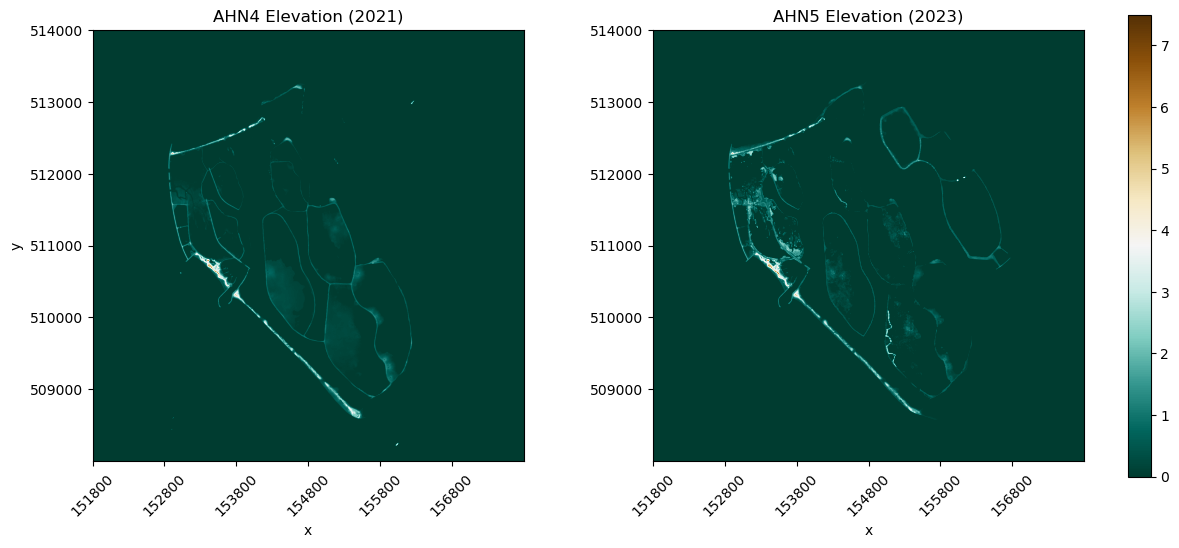

In [145]:
# plot AHN4 on the left and AHN5 on the right (use existing ahn4, ahn5, transform, xtick_labels, ytick_labels)
nrows, ncols = ahn4.shape

# compute map extent from affine transform
xmin = transform.c
xmax = transform.c + ncols * transform.a
ymax = transform.f
ymin = transform.f + nrows * transform.e
extent = (xmin, xmax, ymin, ymax)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.3})

vmin, vmax = 0, 7.5

im0 = axes[0].imshow(ahn4, cmap="BrBG_r", vmin=vmin, vmax=vmax, extent=extent, origin="upper")
axes[0].set_title("AHN4 Elevation (2021)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xticks(xtick_labels)
axes[0].set_yticks(ytick_labels)
axes[0].tick_params(axis="x", rotation=45)

im1 = axes[1].imshow(ahn5, cmap="BrBG_r", vmin=vmin, vmax=vmax, extent=extent, origin="upper")
axes[1].set_title("AHN5 Elevation (2023)")
axes[1].set_xlabel("x")
axes[1].set_xticks(xtick_labels)
axes[1].set_yticks(ytick_labels)
axes[1].tick_params(axis="x", rotation=45)

# Place colorbar to the right of both subplots
cbar = fig.colorbar(im1, ax=axes, location='right', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Min: -5.40259
Max: 9.345329
Mean: 0.0072686817
Std: 0.16710268


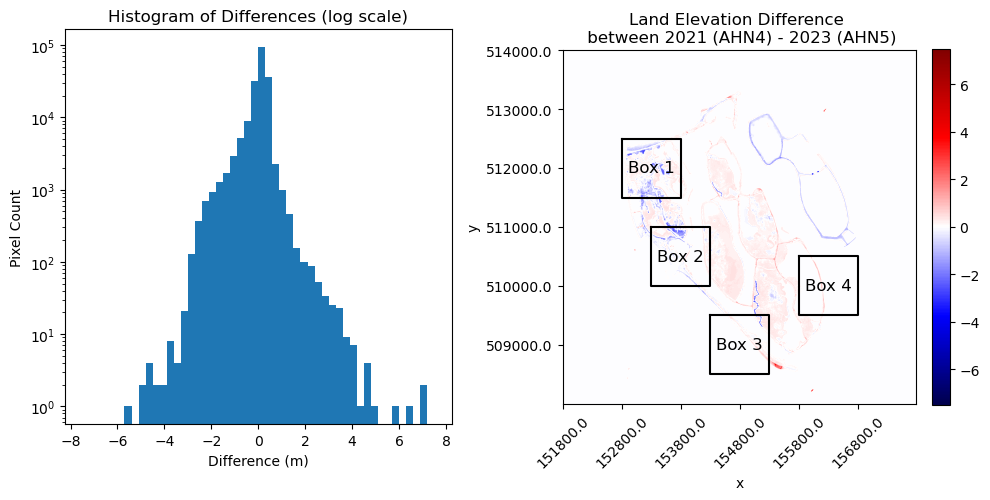

In [133]:
# read ahn45_difference.tiff and print the min, max, mean, std
# also plot a histogram of the values
# also plot the difference as an image

import matplotlib.pyplot as plt
with rasterio.open("data_preprocessed/AHN45/ahn45_difference.tiff") as src:
    difference = src.read(1)
    print("Min:", np.min(difference))
    print("Max:", np.max(difference))
    print("Mean:", np.mean(difference))
    print("Std:", np.std(difference))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    data_nozero = difference.flatten()[difference.flatten() != 0]
    plt.hist(data_nozero, bins=50, range=(-7.5, 7.5), log=True)
    plt.title("Histogram of Differences (log scale)")
    plt.xlabel("Difference (m)")
    plt.ylabel("Pixel Count")

    plt.subplot(1, 2, 2)
    vmax = np.max(np.abs(difference))
    img = plt.imshow(difference, cmap="bwr", vmin=-vmax, vmax=vmax)
    plt.title("Land Elevation Difference \n between 2021 (AHN4) - 2023 (AHN5)")

    # compute tick positions in pixel coordinates
    xticks = np.arange(0, difference.shape[1], 200)
    yticks = np.arange(0, difference.shape[0], 200)

    # convert pixel indices to map coordinates using the affine transform
    # transform * (col, row) -> (x, y)
    xtick_labels = [round((transform * (int(c), 0))[0], 2) for c in xticks]
    ytick_labels = [round((transform * (0, int(r)))[1], 2) for r in yticks]

    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=45)
    plt.yticks(ticks=yticks, labels=ytick_labels)
    # set x y labels
    plt.xlabel("x")
    plt.ylabel("y")

    # Define boxes (in map coordinates)
    boxes = [
        (152800, 511500, 153800, 512500),
        (153300, 510000, 154300, 511000),
        (154300, 508500, 155300, 509500),
        (155800, 509500, 156800, 510500),
    ]

    for i, box in enumerate(boxes, start=1):
        minx, miny, maxx, maxy = box

        # convert corners from map coords (x,y) to pixel coords (col,row)
        col_min = int((~transform * (minx, maxy))[0])  # left
        col_max = int((~transform * (maxx, maxy))[0])  # right
        row_min = int((~transform * (minx, maxy))[1])  # top
        row_max = int((~transform * (minx, miny))[1])  # bottom

        plt.plot(
            [col_min, col_max, col_max, col_min, col_min],
            [row_min, row_min, row_max, row_max, row_min],
            color="black"
        )

        # Place label at box center (map center -> pixel center)
        center_col = int((~transform * ((minx + maxx) / 2, (miny + maxy) / 2))[0])
        center_row = int((~transform * ((minx + maxx) / 2, (miny + maxy) / 2))[1])
        plt.text(center_col, center_row, f"Box {i}", color="black", fontsize=12, ha='center', va='center')

    vmin, vmax = -7.5, 7.5
    img = plt.imshow(difference, cmap="seismic", vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Selected Box 4: (155800, 509500, 156800, 510500)
Box shape (meters): (1000, 1000)
Box shape (pixels, floats): (200.0, 200.0)
Pixel slice rows: (700, 900) cols: (800, 1000)


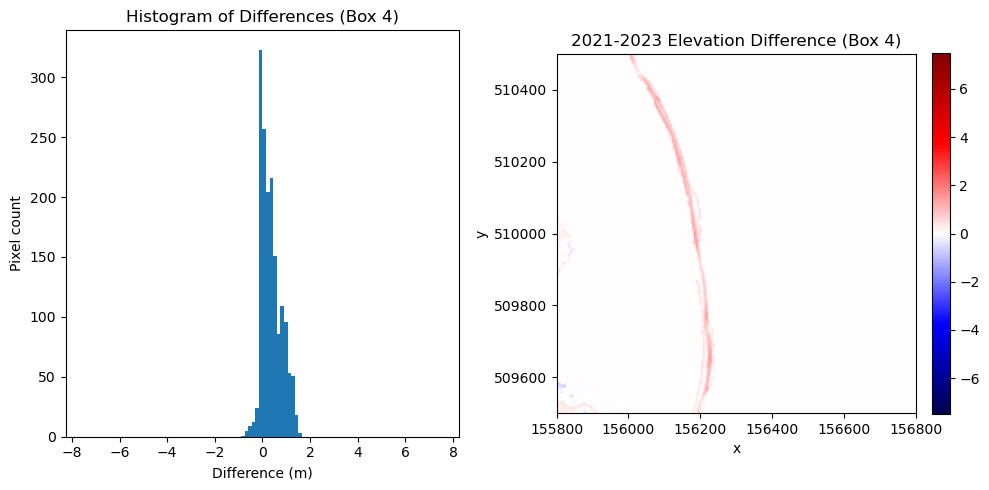

In [ ]:
# change this index to choose a different box (0 to 3)
box_index = 3

if not (0 <= box_index < len(boxes)):
    raise IndexError(f"box_index out of range, must be 0..{len(boxes)-1}")

# select box and show info
box = boxes[box_index]
minx, miny, maxx, maxy = box
print(f"Selected Box {box_index+1}: {box}")

# box size in meters
print("Box shape (meters):", (maxx - minx, maxy - miny))

# convert map coords -> pixel coords using inverse affine
col_min_f, row_min_f = (~transform) * (minx, maxy)
col_max_f, row_max_f = (~transform) * (maxx, miny)

# pixel size (approx)
pixel_width = col_max_f - col_min_f
pixel_height = row_max_f - row_min_f
print("Box shape (pixels, floats):", (pixel_width, pixel_height))

# round and clamp to array bounds
nrows, ncols = difference.shape
col_min = max(0, min(ncols, int(round(col_min_f))))
col_max = max(0, min(ncols, int(round(col_max_f))))
row_min = max(0, min(nrows, int(round(row_min_f))))
row_max = max(0, min(nrows, int(round(row_max_f))))

# ensure proper ordering for slicing
row0, row1 = sorted((row_min, row_max))
col0, col1 = sorted((col_min, col_max))

print("Pixel slice rows:", (row0, row1), "cols:", (col0, col1))

crop = difference[row0:row1, col0:col1]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
data_nozero = crop.flatten()[crop.flatten() != 0]
plt.hist(data_nozero, bins=100, range=(vmin, vmax))
plt.title(f"Histogram of Differences (Box {box_index+1})")
plt.xlabel("Difference (m)")
plt.ylabel("Pixel count")

plt.subplot(1, 2, 2)
# show crop with map coordinate extent so axes show real coordinates
img = plt.imshow(crop, cmap="seismic", vmin=vmin, vmax=vmax,
                 extent=(minx, maxx, miny, maxy), origin="upper")
plt.title(f"2021-2023 Elevation Difference (Box {box_index+1})")
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(img, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
